
# **Analysis using Clustering with the K-MEANS model**


## **Helper Functions and variables**

### Define Colors, iconicity and categories

In [1]:
import pandas as pd
!pip install distinctipy
!pip install adjustText

In [2]:
# ==============================================================================
# DEFINE COLORS AND ICONICITY CATEGORIES
# ==============================================================================

# Categorías de iconicidad (8 niveles)
CATEGORY_COLORS = {
    1: '#8b0000',  # Rojo oscuro
    2: '#e74c3c',  # Rojo
    3: '#ff6b35',  # Naranja rojizo
    4: '#f39c12',  # Naranja
    5: '#f1c40f',  # Amarillo
    6: '#3498db',  # Azul claro
    7: '#2874a6',  # Azul oscuro
    8: '#9b59b6'   # Morado
}

CATEGORY_LABELS = {
    1: '1.0-1.5', 2: '1.5-2.0', 3: '2.0-2.5', 4: '2.5-3.0',
    5: '3.0-3.5', 6: '3.5-4.0', 7: '4.0-4.5', 8: '4.5-5.0'
}

# Colores para clusters K-Means (10 colores máximo)

# CLUSTER_COLORS = [
#     "#FF0000",  # Rojo
#     "#0000FF",  # Azul
#     "#00FF00",  # Verde
#     "#FFFF00",  # Amarillo
#     "#FF00FF",  # Magenta
#     "#00FFFF",  # Cian
#     "#D9D9D9",  # Negro
#     "#FFA500",  # Naranja
#     "#8B4513",  # Marrón
#     "#800080"   # Morado
# ]

CLUSTER_COLORS = [
    "#1F77B4",  # azul
    "#FF7F0E",  # naranja
    "#2CA02C",  # verde
    "#D62728",  # rojo
    "#9467BD",  # morado
    "#8C564B",  # marrón
    "#E377C2",  # rosa
    "#7F7F7F",  # gris
    "#BCBD22",  # oliva
    "#17BECF"   # cian
]


def categorize_iconicity_8(icon):
    """Categorizar iconicidad en 8 niveles"""
    if icon <= 1.5: return 1
    elif icon <= 2.0: return 2
    elif icon <= 2.5: return 3
    elif icon <= 3.0: return 4
    elif icon <= 3.5: return 5
    elif icon <= 4.0: return 6
    elif icon <= 4.5: return 7
    else: return 8


### Elbow Method

In [ ]:
# ==============================================================================
# MÉTODO DEL CODO (ELBOW METHOD)
#==============================================================================

def elbow_method(X, lang_name, k_range=range(2, 11)):
    """Aplicar método del codo para encontrar k óptimo"""

    print(f"\n🔹 {lang_name}:")

    inertias = []
    silhouette_scores = []
    davies_bouldin_scores = []
    calinski_harabasz_scores = []
    listModels = []
    for k in k_range:
        kmeans = KMeans(n_clusters=k, n_init=50, max_iter=500, random_state=42)
        kmeans.fit(X)
        inertias.append(kmeans.inertia_)
        silhouette_scores.append(silhouette_score(X, kmeans.labels_))
        davies_bouldin_scores.append(davies_bouldin_score(X, kmeans.labels_))
        calinski_harabasz_scores.append(calinski_harabasz_score(X, kmeans.labels_))
        listModels.append(kmeans)

    # Calcular "codo" (máxima curvatura)
    # Método: segunda derivada
    inertias_arr = np.array(inertias)
    if len(inertias_arr) > 2:
        first_deriv = np.diff(inertias_arr)
        second_deriv = np.diff(first_deriv)
        elbow_idx = np.argmax(np.abs(second_deriv)) + 2  # +2 porque perdemos 2 puntos
        k_optimal = list(k_range)[elbow_idx]
    else:
        k_optimal = 3  # Default

    k_list = list(k_range)
    print(f"\n   💡 k óptimo sugerido (método del codo): {k_optimal}")
    print(f"   💡 k con mejor Silhouette:        {k_list[np.argmax(silhouette_scores)]} (↑ mayor es mejor)")
    print(f"   💡 k con mejor Davies-Bouldin:    {k_list[np.argmin(davies_bouldin_scores)]} (↓ menor es mejor)")
    print(f"   💡 k con mejor Calinski-Harabasz: {k_list[np.argmax(calinski_harabasz_scores)]} (↑ mayor es mejor)")

    return inertias, silhouette_scores, davies_bouldin_scores, calinski_harabasz_scores, k_optimal


### Plot k-means

In [4]:
def plot_kmeans_clusters(data, lang_name, k_optimal, filename):
    """Graficar clusters K-Means con todas las señas etiquetadas"""

    print(f"\n📊 Generando gráfica para {lang_name}...")

    fig, ax = plt.subplots(figsize=(16, 14))

    # Scatter por cluster
    for c in range(k_optimal):
        cluster_data = data[data['cluster'] == c]
        ax.scatter(
            cluster_data['tsne_x'], cluster_data['tsne_y'],
            c=CLUSTER_COLORS[c % len(CLUSTER_COLORS)],
            s=350,
            alpha=0.7,
            edgecolors='black',
            linewidths=1.5,
            label=f'Cluster {c} (n={len(cluster_data)})',
            zorder=3
        )

    # Etiquetar TODAS las señas
    print(f"   🔹 Etiquetando {len(data)} señas...")
    for _, row in data.iterrows():
        annotation_text = ax.annotate(
            row['word'].lower(),
            (row['tsne_x'], row['tsne_y']), # tsne_x, tsne_y
            fontsize=12,
            fontweight='bold',
            xytext=(5, 5),
            textcoords='offset points',
            alpha=0.8,
            zorder=4
        )
        annotation_text.set_url("https://diccionariolsp.pucp.edu.pe/search-by-text")

    ax.set_title(f'{lang_name}: K-Means Clustering (k={k_optimal})',
                 fontsize=16, fontweight='bold', pad=20)
    # dim_reduc_method brings the proper information for axis names
    ax.set_xlabel('TSNE Dimension 1', fontsize=13, fontweight='bold')
    ax.set_ylabel('TSNE Dimension 2', fontsize=13, fontweight='bold')
    ax.legend(loc='best', fontsize=10, framealpha=0.9)
    ax.grid(True, alpha=0.2)
    ax.set_xticks([])
    ax.set_yticks([])

    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

    print(f"   ✅ {filename} guardada")

In [5]:
from adjustText import adjust_text

def plot_kmeans_clusters_new(data, lang_name, k_optimal, filename):
    """Graficar clusters K-Means con todas las señas etiquetadas (estable)."""

    print(f"\n📊 Generando gráfica para {lang_name}...")

    fig, ax = plt.subplots(figsize=(22, 18))

    # 1) Scatter por cluster
    for c in range(k_optimal):
        cluster_data = data[data['cluster'] == c]
        ax.scatter(
            cluster_data['tsne_x'], cluster_data['tsne_y'],
            c=CLUSTER_COLORS[c % len(CLUSTER_COLORS)],
            s=350,
            alpha=0.7,
            edgecolors='black',
            linewidths=1.5,
            label=f'Cluster {c} (n={len(cluster_data)})',
            zorder=3
        )

    # Guarda límites y EXPÁNDELOS ligeramente
    ax.autoscale(True)  # Primero autoscale
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # Expande límites 5% para incluir outliers
    x_range = xlim[1] - xlim[0]
    y_range = ylim[1] - ylim[0]
    xlim_expanded = (xlim[0] - 0.05*x_range, xlim[1] + 0.05*x_range)
    ylim_expanded = (ylim[0] - 0.05*y_range, ylim[1] + 0.05*y_range)

    # FILTRAR puntos dentro de límites expandidos
    data_visible = data[
        (data['tsne_x'] >= xlim_expanded[0]) &
        (data['tsne_x'] <= xlim_expanded[1]) &
        (data['tsne_y'] >= ylim_expanded[0]) &
        (data['tsne_y'] <= ylim_expanded[1])
    ].copy()

    n_filtered = len(data) - len(data_visible)
    if n_filtered > 0:
        print(f"⚠️ {n_filtered} puntos outliers excluidos del etiquetado")

    ax.autoscale(False)  # Ahora sí congela límites
    ax.set_xlim(xlim_expanded)
    ax.set_ylim(ylim_expanded)

    # 2) Crear etiquetas SOLO para puntos visibles
    texts = []
    for _, row in data_visible.iterrows():
        txt = ax.text(
            float(row["tsne_x"]),
            float(row["tsne_y"]),
            str(row["word"]).lower(),
            fontsize=10,
            alpha=0.9,
            zorder=4,
            ha='center',
            va='center',
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="lightgray",
                     alpha=0.9, linewidth=0.5)
        )
        texts.append(txt)

    # AJUSTE OPTIMIZADO
    adjust_text(
        texts,
        ax=ax,

        # Mantiene textos cerca de puntos
        force_pull=(1.2, 1.2),
        force_explode=(0.6, 0.6),

        # Movimiento moderado
        only_move={'text': 'xy'},
        max_move=(12, 12),

        # Separación
        expand_text=(1.06, 1.06),
        force_text=(0.08, 0.08),
        force_points=(0.04, 0.04),

        # Flechas para textos alejados
        arrowprops=dict(
            arrowstyle='-',
            color='gray',
            lw=0.5,
            alpha=0.4
        ),

        # Iteraciones
        lim=150,

        # NO expandir el gráfico
        expand_points=(1.0, 1.0),
        expand_objects=(1.0, 1.0)
    )

    # 3) Estética
    ax.set_title(f"{lang_name}: K-Means Clustering (k={k_optimal})",
                 fontsize=18, fontweight="bold", pad=20)
    ax.set_xlabel("TSNE Dimension 1", fontsize=14, fontweight="bold")
    ax.set_ylabel("TSNE Dimension 2", fontsize=14, fontweight="bold")

    ax.legend(loc="best", fontsize=10, framealpha=0.95,
              title=f"{len(data_visible)}/{len(data)} signs shown")
    ax.grid(True, alpha=0.15)
    ax.set_xticks([])
    ax.set_yticks([])

    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()

    print(f"✅ {filename} guardada ({len(data_visible)} etiquetas)")

In [6]:

def plot_clusters_iconicity_size(data, lang_name, k_optimal, filename):
    """Clusters con color, iconicidad con tamaño"""

    print(f"\n📊 Generando gráfica para {lang_name}...")

    fig, ax = plt.subplots(figsize=(18, 14))

    # Normalizar iconicidad para tamaño de puntos (50-500)
    icon_normalized = (data['iconicity'] - data['iconicity'].min()) / \
                      (data['iconicity'].max() - data['iconicity'].min())
    sizes = 80 + icon_normalized * 400  # Tamaño de 80 a 480

    # Scatter por cluster con tamaño por iconicidad
    for c in range(k_optimal):
        cluster_data = data[data['cluster'] == c]
        cluster_sizes = sizes[data['cluster'] == c]

        ax.scatter(
            cluster_data['tsne_x'], cluster_data['tsne_y'],
            c=CLUSTER_COLORS[c % len(CLUSTER_COLORS)],
            # c=CLUSTER_COLORS[c],
            s=cluster_sizes,
            alpha=0.6,
            edgecolors='black',
            linewidths=1.5,
            label=f'Cluster {c}',
            zorder=3
        )

    # Etiquetar TODAS las señas con iconicidad
    print(f"   🔹 Etiquetando {len(data)} señas...")
    for _, row in data.iterrows():
        label = f"{row['word'].lower()} ({row['iconicity']:.2f})"
        ax.annotate(
            label,
            (row['tsne_x'], row['tsne_y']),
            fontsize=8,
            fontweight='bold',
            xytext=(3, 3),
            textcoords='offset points',
            alpha=0.75,
            zorder=4
        )

    ax.set_title(f'{lang_name}: K-Means Clusters + Iconicity\n' +
                 f'Color = Cluster, Size = Iconicity',
                 fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('TSNE Dimension 1', fontsize=13, fontweight='bold')
    ax.set_ylabel('TSNE Dimension 2', fontsize=13, fontweight='bold')

    # Leyenda de clusters
    ax.legend(loc='upper left', fontsize=10, framealpha=0.9, title='Clusters',
             title_fontsize=11)

    # Agregar texto explicativo de tamaños
    textstr = 'Size = Iconicity\nSmaller = Lower\nLarger = Higher'
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    ax.text(0.98, 0.02, textstr, transform=ax.transAxes, fontsize=11,
            verticalalignment='bottom', horizontalalignment='right', bbox=props)

    ax.grid(True, alpha=0.2)
    ax.set_xticks([])
    ax.set_yticks([])

    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

    print(f" {filename} guardada")

In [7]:
def plot_facet_grid_clusters(data, lang_name, k_optimal, filename):
    """Facet grid: subplot por cluster, color por iconicidad"""

    print(f"\n Generando facet grid para {lang_name}...")

    # Calcular grid óptimo
    n_cols = min(3, k_optimal)
    n_rows = (k_optimal + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
    axes = axes.flatten() if k_optimal > 1 else [axes]

    for c in range(k_optimal):
        ax = axes[c]
        cluster_data = data[data['cluster'] == c]

        # Scatter por categoría de iconicidad
        for cat in range(1, 9):
            cat_data = cluster_data[cluster_data['icon_category'] == cat]
            if len(cat_data) > 0:
                ax.scatter(
                    cat_data['tsne_x'], cat_data['tsne_y'], # tsne_x, tsne_y
                    c=CATEGORY_COLORS[cat],
                    s=100,
                    alpha=0.7,
                    edgecolors='black',
                    linewidths=1.2,
                    label=CATEGORY_LABELS[cat],
                    zorder=3
                )

        # Etiquetar señas del cluster
        print(f" Cluster {c}: Etiquetando {len(cluster_data)} señas...")
        for _, row in cluster_data.iterrows():
            ax.annotate(
                row['word'].lower(),
                (row['tsne_x'], row['tsne_y']),
                fontsize=8,
                fontweight='bold',
                xytext=(2, 2),
                textcoords='offset points',
                alpha=0.8,
                zorder=4
            )

        ax.set_title(f'Cluster {c} (n={len(cluster_data)})',
                    fontsize=12, fontweight='bold')
        ax.set_xlabel('tsne_x', fontsize=10)
        ax.set_ylabel('tsne_y', fontsize=10)
        ax.legend(fontsize=7, loc='best', framealpha=0.9, ncol=2)
        ax.grid(True, alpha=0.2)
        ax.set_xticks([])
        ax.set_yticks([])

    # Ocultar subplots vacíos
    for idx in range(k_optimal, len(axes)):
        axes[idx].set_visible(False)

    fig.suptitle(f'{lang_name}: Facet Grid by Cluster\n' +
                 f'Color = Iconicity Category',
                 fontsize=16, fontweight='bold', y=0.995)

    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

    print(f"{filename} guardada")

In [8]:
def plot_pca_3d_iconicity(data, pca_obj, lang_name, filename):
    """PCA 3D con color por categoría de iconicidad"""

    print(f"\n📊 Generando gráfica 3D para {lang_name}...")

    fig = plt.figure(figsize=(18, 14))
    ax = fig.add_subplot(111, projection='3d')

    # Scatter por categoría de iconicidad
    for cat in range(1, 9):
        cat_data = data[data['icon_category'] == cat]
        if len(cat_data) > 0:
            ax.scatter(
                cat_data['x'], cat_data['y'], cat_data['z'],
                c=CATEGORY_COLORS[cat],
                s=120,
                alpha=0.7,
                edgecolors='black',
                linewidths=1.2,
                label=f'{CATEGORY_LABELS[cat]}',
                depthshade=True
            )

    # Etiquetar TODAS las señas
    print(f"Etiquetando {len(data)} señas en 3D...")
    for _, row in data.iterrows():
        label = f"{row['word'].lower()} ({row['iconicity']:.2f})"
        ax.text(
            row['x'], row['y'], row['z'],
            label,
            fontsize=7,
            fontweight='bold',
            alpha=0.7
        )

    # Varianza explicada
    var1 = pca_obj.explained_variance_ratio_[0] * 100
    var2 = pca_obj.explained_variance_ratio_[1] * 100
    var3 = pca_obj.explained_variance_ratio_[2] * 100

    ax.set_xlabel(f'PC1 ({var1:.1f}% var)', fontsize=12, fontweight='bold')
    ax.set_ylabel(f'PC2 ({var2:.1f}% var)', fontsize=12, fontweight='bold')
    ax.set_zlabel(f'PC3 ({var3:.1f}% var)', fontsize=12, fontweight='bold')

    ax.set_title(f'{lang_name}: Iconicity in PCA 3D Space\n' +
                 f'Total Variance Explained: {var1+var2+var3:.1f}%',
                 fontsize=16, fontweight='bold', pad=20)

    ax.legend(loc='upper left', fontsize=9, framealpha=0.9, ncol=2,
             title='Iconicity Category')

    # Ajustar ángulo de visualización
    ax.view_init(elev=20, azim=45)

    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

    print(f"{filename} guardada")

In [9]:
def plot_pca_tsne_3d_iconicity(data, pca_obj, k_optimal, lang_name, filename):
    """PCA-TSNE 3D con color por categoría de iconicidad"""

    fig = plt.figure(figsize=(18, 14))
    ax = fig.add_subplot(111, projection='3d')

    # Scatter por categoría de iconicidad


    # Scatter por cluster
    for c in range(k_optimal):
        cluster_data = data[data['cluster'] == c]
        ax.scatter(
            cluster_data['tsne_x_3d'], cluster_data['tsne_y_3d'], cluster_data['tsne_z_3d'],
            c=CLUSTER_COLORS[c % len(CLUSTER_COLORS)],
            # c=CLUSTER_COLORS[c],
            s=120,
            alpha=0.7,
            edgecolors='black',
            linewidths=1.5,
            label=f'Cluster {c} (n={len(cluster_data)})',
            zorder=3
        )

    # Etiquetar TODAS las señas
    # for _, row in data.iterrows():
    #     annotation_text = ax.annotate(
    #         (row['tsne_x_3d'], row['tsne_y_3d']),row['tsne_z_3d'], # tsne_x, tsne_y
    #         fontsize=8,
    #         fontweight='bold',
    #         xytext=(3, 3),
    #         textcoords='offset points',
    #         alpha=0.8,
    #         zorder=4
    #         )

    scale = data[['tsne_x_3d','tsne_y_3d','tsne_z_3d']].to_numpy()
    offset = 0.02 * (scale.max() - scale.min())

    for _, row in data.iterrows():
        ax.text(
            row['tsne_x_3d'] + offset,
            row['tsne_y_3d'] + offset,
            row['tsne_z_3d'] + offset,
            str(row['word']),
            fontsize=8,
            fontweight='bold',
            alpha=0.8,
            zorder=4
        )
    # Varianza explicada
    var1 = pca_obj.explained_variance_ratio_[0] * 100
    var2 = pca_obj.explained_variance_ratio_[1] * 100
    var3 = pca_obj.explained_variance_ratio_[2] * 100

    ax.set_xlabel(f'PCA-TSNE1 ({var1:.1f}% var)', fontsize=12, fontweight='bold')
    ax.set_ylabel(f'PCA-TSNE2 ({var2:.1f}% var)', fontsize=12, fontweight='bold')
    ax.set_zlabel(f'PCA-TSNE3 ({var3:.1f}% var)', fontsize=12, fontweight='bold')

    ax.set_title(f'{lang_name}: Iconicity in PCA-TSNE 3D Space\n' +
                 f'Total Variance Explained: {var1+var2+var3:.1f}%',
                 fontsize=16, fontweight='bold', pad=20)

    ax.legend(loc='upper left', fontsize=9, framealpha=0.9, ncol=2, title="")

    # Ajustar ángulo de visualización
    ax.view_init(elev=20, azim=45)

    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

    print(f"{filename} guardada")

### Helpers for Options to Reduce Dimensionality TSNE, PCA and KMeans

In [10]:
def apply_kmeans(X, data, k_optimal, lang_name):
    """Aplicar K-Means con k óptimo"""

    print(f"\n{lang_name} con k={k_optimal}:")

    kmeans = KMeans(n_clusters=k_optimal, n_init=50, max_iter=500, random_state=42)
    clusters = kmeans.fit_predict(X)

    # Métricas de calidad
    silhouette = silhouette_score(X, clusters)
    davies_bouldin = davies_bouldin_score(X, clusters)

    print(f"   Clustering completado")
    print(f"   Silhouette Score: {silhouette:.3f} (más cerca de 1 = mejor)")
    print(f"   Davies-Bouldin Index: {davies_bouldin:.3f} (más cerca de 0 = mejor)")

    # Asignar clusters
    data['cluster'] = clusters

    # Estadísticas por cluster
    print(f"\n   Distribución de señas por cluster:")
    for c in range(k_optimal):
        count = (clusters == c).sum()
        pct = (count / len(clusters)) * 100
        mean_icon = data[data['cluster'] == c]['iconicity'].mean()
        print(f"      Cluster {c}: {count} señas ({pct:.1f}%) - Iconicidad media: {mean_icon:.2f}")

    return data

In [11]:
def analyze_clusters(data, lang_name, k_optimal):
    """Análisis detallado de clusters"""

    print(f"\n{'='*60}")
    print(f"{lang_name} - ANÁLISIS DE CLUSTERS (k={k_optimal})")
    print(f"{'='*60}")

    stats_text = []
    stats_text.append(f"\n{lang_name} - ANÁLISIS DE CLUSTERS (k={k_optimal})\n")
    stats_text.append("="*60 + "\n")

    for c in range(k_optimal):
        cluster_data = data[data['cluster'] == c]

        print(f"\n CLUSTER {c}:")
        stats_text.append(f"\nCLUSTER {c}:\n")
        stats_text.append("-"*40 + "\n")

        # Tamaño
        size = len(cluster_data)
        pct = (size / len(data)) * 100
        print(f"   • Tamaño: {size} señas ({pct:.1f}%)")
        stats_text.append(f"Tamaño: {size} señas ({pct:.1f}%)\n")

        # Iconicidad
        icon_mean = cluster_data['iconicity'].mean()
        icon_std = cluster_data['iconicity'].std()
        icon_min = cluster_data['iconicity'].min()
        icon_max = cluster_data['iconicity'].max()
        print(f"   • Iconicidad: {icon_mean:.2f} ± {icon_std:.2f} (rango: {icon_min:.2f} - {icon_max:.2f})")
        stats_text.append(f"Iconicidad: {icon_mean:.2f} ± {icon_std:.2f} (rango: {icon_min:.2f} - {icon_max:.2f})\n")

        # Top 5 señas
        top_5 = cluster_data.nlargest(5, 'iconicity')
        print(f"   • Top 5 más icónicas:")
        stats_text.append("Top 5 más icónicas:\n")
        for _, row in top_5.iterrows():
            print(f"      {row['word']:15s} → {row['iconicity']:.2f}")
            stats_text.append(f"  {row['word']:15s} → {row['iconicity']:.2f}\n")

        # Todas las palabras del cluster
        words = sorted(cluster_data['word'].tolist())
        print(f"   • Todas las señas ({len(words)}):")
        print(f"      {', '.join(words[:20])}" + ("..." if len(words) > 20 else ""))
        stats_text.append(f"Todas las señas: {', '.join(words)}\n")

    return ''.join(stats_text)

In [12]:
# ==============================================================================
# REDUCCIÓN DIMENSIONAL CON PCA
# ==============================================================================

from numpy.ma.core import var
from sklearn.decomposition import PCA

print("\n" + "="*80)
print("🔬 PASO 2: REDUCCIÓN DIMENSIONAL (PCA)")
print("="*80)

def apply_pca(data, embedding_cols, lang_name):
    """Aplicar PCA a embeddings"""

    print(f"\n📊 {lang_name}:")

    X = data[embedding_cols].values

    # PCA a 50 componentes (para K-Means)
    print("   🔹 PCA a 50 componentes (para clustering)...")
    pca_50 = PCA(n_components=50, random_state=42)
    X_pca_50 = pca_50.fit_transform(X)
    var_50 = pca_50.explained_variance_ratio_.sum()
    print(f"   ✅ Varianza explicada (50 PC): {var_50:.1%}")

    # PCA a 3 componentes (para visualización 3D)
    print("   🔹 PCA a 3 componentes (para visualización 3D)...")
    pca_3 = PCA(n_components=3, random_state=42)
    X_pca_3 = pca_3.fit_transform(X)
    var_3 = pca_3.explained_variance_ratio_.sum()
    print(f"   ✅ Varianza explicada (3 PC): {var_3:.1%}")
    print(f"      PC1: {pca_3.explained_variance_ratio_[0]:.1%}")
    print(f"      PC2: {pca_3.explained_variance_ratio_[1]:.1%}")
    print(f"      PC3: {pca_3.explained_variance_ratio_[2]:.1%}")


    # PCA a 2 componentes (para visualización 2D si se necesita)
    print("   🔹 PCA a 2 componentes ")
    pca_2 = PCA(n_components=2, random_state=42)
    X_pca_2 = pca_2.fit_transform(X)
    var_2 = pca_2.explained_variance_ratio_.sum()
    print(f"   ✅ Varianza explicada (2 PC): {var_2:.1%}")
    print(f"      PC1: {pca_2.explained_variance_ratio_[0]:.1%}")
    print(f"      PC2: {pca_2.explained_variance_ratio_[1]:.1%}")

    # return X_pca_50, X_pca_3, X_pca_2, pca_3
    return X_pca_50, pca_50



🔬 PASO 2: REDUCCIÓN DIMENSIONAL (PCA)


In [13]:

def apply_tsne(X, lang_name):
    """Aplicar T-SNE sobre embeddings PCA"""

    perplexity = min(30, len(X) // 4)
    # perplexity = min(25, len(X) // 3)
    tsne = TSNE(n_components=2, metric='cosine', perplexity=perplexity,
                random_state=42, n_iter=1000, verbose=0)
    coords_tsne = tsne.fit_transform(X)

    print(f"   ✅ T-SNE completado")

    return coords_tsne


# coords_tsne = apply_tsne_new(X_50, "LSP")

# sign_data['tsne_x'] = coords_tsne[:, 0]
# sign_data['tsne_y'] = coords_tsne[:, 1]


# perp = min(25, N // 3)
# tsne = TSNE(
#     n_components=2, learning_rate="auto", metric="cosine",
#     init="pca", n_iter=1000, random_state=42, method="exact"
# )

In [14]:
def apply_tsne_3d(X, lang_name):
    """Aplicar T-SNE sobre embeddings PCA"""

    perplexity = min(30, len(X) // 4)
    tsne = TSNE(n_components=3, metric='cosine', perplexity=perplexity,
                random_state=42, n_iter=1000, verbose=0)
    coords_tsne = tsne.fit_transform(X)

    print(f"   ✅ T-SNE completado")

    return coords_tsne

In [15]:
'''
def reduce_to_2d_PCA(data, embedding_cols, lang_name):
    """Reducir embeddings a 2D usando PCA"""
    X = lsp_data[embedding_cols].values
    pca = PCA(n_components=50, random_state=42)
    X_pca = pca.fit_transform(X)
    #var_explained = pca.explained_variance_ratio_.sum()
    #print(f"   ✅ Varianza explicada: {var_explained:.1%}")
    return X_pca, pca
'''

'\ndef reduce_to_2d_PCA(data, embedding_cols, lang_name):\n    """Reducir embeddings a 2D usando PCA"""\n    X = lsp_data[embedding_cols].values\n    pca = PCA(n_components=50, random_state=42)\n    X_pca = pca.fit_transform(X)\n    #var_explained = pca.explained_variance_ratio_.sum()\n    #print(f"   ✅ Varianza explicada: {var_explained:.1%}")\n    return X_pca, pca\n'

In [16]:
'''
def reduce_to_2d_TSNE(data, embedding_cols, lang_name):
    """Reducir embeddings a 2D usando PCA + T-SNE"""
    print(f"\n📊 {lang_name}:")

    X = data[embedding_cols].values
    perplexity = min(30, X.shape[0] // 4)
    tsne = TSNE(
        n_components=2,
        metric='cosine',
        perplexity=perplexity,
        random_state=42,
        n_iter=1000,
        verbose=0
    )
    coords_2d = tsne.fit_transform(X)
    return coords_2d, tsne

'''

'\ndef reduce_to_2d_TSNE(data, embedding_cols, lang_name):\n    """Reducir embeddings a 2D usando PCA + T-SNE"""\n    print(f"\n📊 {lang_name}:")\n\n    X = data[embedding_cols].values\n    perplexity = min(30, X.shape[0] // 4)\n    tsne = TSNE(\n        n_components=2,\n        metric=\'cosine\',\n        perplexity=perplexity,\n        random_state=42,\n        n_iter=1000,\n        verbose=0\n    )\n    coords_2d = tsne.fit_transform(X)\n    return coords_2d, tsne\n\n'

In [17]:
def reduce_to_2d_PCA_TSNE(data, embedding_cols, lang_name):
    """Reducir embeddings a 2D usando PCA + T-SNE"""

    print(f"\n📊 {lang_name}:")

    X = data[embedding_cols].values

    # PCA primero
    print("   🔹 PCA a 50 componentes...")
    n_components_pca = min(50, X.shape[0] - 1, X.shape[1])
    pca = PCA(n_components=n_components_pca, random_state=42)
    X_pca = pca.fit_transform(X)
    var_explained = pca.explained_variance_ratio_.sum()
    print(f"   ✅ Varianza explicada: {var_explained:.1%}")

    # T-SNE a 2D
    print("   🔹 T-SNE a 3D...")
    perplexity = min(30, X.shape[0] // 4)
    tsne = TSNE(
        n_components=2,
        metric='cosine',
        perplexity=perplexity,
        random_state=42,
        n_iter=1000,
        verbose=0
    )
    coords_2d = tsne.fit_transform(X_pca)

    print(f"   ✅ Reducción completada")

    return coords_2d, tsne

### Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.stats import gaussian_kde
from google.colab import files
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-white')

## **Read input files**

*   The input datasets are the model embeddings (MHI, signERT, "MHI + signERT") associated with iconicity (which were obtained from the notebook **Script_merge_iconicity_embeddings**)

*   The version number is with respesct to the model version.

*   After conducting several tests with different versions and models, the MHI model with version V3 gave us the best results. The following table shows the summary:



      | N° | Language | Method | Version | Dimensiones | Descripción de modelos usados | Descripción de salida de inferencia |
      |----|----------|--------|---------|-------------|--------------------------------|------------------------------------|
      | 1  | LSP      | MHI    | v3      | 4064        | MHI y Triplet entrenado usando LSP Iconicity105 | Mediana representativa por glosa de Iconicity105 |
      | 2  | ASL      | MHI    | v3      | 4064        | MHI y Triplet entrenado usando LSP Iconicity105 | Muestra de los videos de Lewis y Larry |


*   The models that were tested have the following dimensions:
    *   MHI-Only : 4064 dimensions.
    *   signERT: 192 dimensions.
    *   "MHI + signERT": combined 4256 dimensions


### **Type of Phonological Embedding: Examples of the datasets that were tested:**

*   MHI-Only: gets the emedding from the Movement Historic Image
    1.   ASL: emb_phono_ASL_MHIv3.csv
    2.   LSP: emb_phono_LSP_MHIv3.csv

*   signERT: gets the embedding from the very previous to the last layer form the model signERT
    1.   ASL: emb_phono_ASL_signERTv1.csv
    2.   LSP: emb_phono_LSP_signERTv1.csv

*   MHI-signERT:  gets the embedding by combining MHI and the keypoints
    1.   ASL: emb_phono_ASL_MHIv3signERTv1.csv
    2.   LSP: emb_phono_ASL_MHIv3signERTv1.csv

### **Type of Semantic Embedding**

*   ASL: emb_semantic_RAW_ASL_FASTTEXT.csv
*   LSP: emb_semantic_RAW_LSP_FASTTEXT.csv


### **Type of Reduction**

*   PCA
*   TSNE
*   PCA_TSNE



### **1. Experimental Setup for Clustering Analysis**

In [19]:
# ==============================================================================
# DATA LOADING
# ==============================================================================
import os
signLanguage = "LSP"
fileName = 'emb_phono_median_LSP_MHIv5'
sign_data = pd.read_csv(fileName+'.csv')

#asl_data = pd.read_csv('emb_phono_ASL_MHIv2' + '.csv')
#lsp_data = pd.read_csv(fileName+'.csv')
os.makedirs(f"{fileName}/", exist_ok=True)

# Identificar columnas de embeddings
exclude_cols = ['word', 'iconicity','category', 'x', 'y']
embedding_cols = [col for col in sign_data.columns if col not in exclude_cols and pd.api.types.is_numeric_dtype(sign_data[col])]

# Categorizar iconicidad
#asl_data['icon_category'] = asl_data['iconicity'].apply(categorize_iconicity_8)
sign_data['icon_category'] = sign_data['iconicity'].apply(categorize_iconicity_8)


In [20]:
# ==============================================================================
# SELECT DIMENSIONALITY REDUCTION METHOD FOR 2D VISUALIZATION
# ==============================================================================

pca_dict = {'methodReduction' : "PCA", 'red_components' :['pca1','pca2']} #'name_components' : ['PCA 1','PCA 2']
tsne_dict = {'methodReduction' : "TSNE", 'red_components' : ['tsne_x','tsne_y']} # 'name_components' : ['TSNE Dim1','TSNE Dim2']
pca_tsne_dict = {'methodReduction' : "PCA_TSNE", 'red_components' : ['pca_tsne_x','pca_txne_y']} # 'name_components' : ['PCA_TSNE Dim1','PCA_TSNE Dim2']

reduct_method = pca_tsne_dict


In [21]:
# ==============================================================================
# SELECT CLUSTER NUMBER
# ==============================================================================
k_opt = 10

### **2. Apply dimensionality reduction**

In [22]:
# ==============================================================================
# PCA-BASED DIMENSIONALITY REDUCTION AND VARIANCE ANALYSIS
# ==============================================================================

from sklearn.manifold import TSNE

# Aplicar PCA
#X_asl_50, pca_asl_3 = apply_pca(asl_data, embedding_cols, "ASL")
#X_lsp_50, pca_lsp_3 = apply_pca(lsp_data, embedding_cols, "LSP")


print("\n" + "="*80)
print("🔬 PASO 2: REDUCCIÓN DIMENSIONAL (PCA)")
print("="*80)

# if reduct_method['methodReduction'] == "PCA":
#   coords , reduc_model = apply_pca(sign_data, embedding_cols, signLanguage)
#   #coords_asl, reduc_model = apply_pca(asl_data, embedding_cols, "ASL")
#   sign_data['x'] = coords[:, 0] # sign_data['pc1'] = coords_lsp[:, 0]
#   sign_data['y'] = coords[:, 1]
#   sign_data['z'] = coords[:, 2]
# elif reduct_method['methodReduction'] == "PCA_TSNE":
#   coords, reduc_model = reduce_to_2d_PCA_TSNE(sign_data, embedding_cols, signLanguage)
#   #coords_asl, reduc_model = reduce_to_2d_PCA_TSNE(asl_data, embedding_cols, "ASL")
#   sign_data['x'] = coords[:, 0] # sign_data['pc1'] = coords_lsp[:, 0]
#   sign_data['y'] = coords[:, 1]

# else:
#   print("Pick method for reduction")

coords , reduc_model = apply_pca(sign_data, embedding_cols, signLanguage)

sign_data['x'] = coords[:, 0]
sign_data['y'] = coords[:, 1]
sign_data['z'] = coords[:, 2]


# Guardar en dataframes
#asl_data['pc1'] = coords_asl[:, 0]
#asl_data['pc2'] = coords_asl[:, 1]
#asl_data['pc3'] = coords_asl[:, 2]



🔬 PASO 2: REDUCCIÓN DIMENSIONAL (PCA)

📊 LSP:
   🔹 PCA a 50 componentes (para clustering)...
   ✅ Varianza explicada (50 PC): 92.1%
   🔹 PCA a 3 componentes (para visualización 3D)...
   ✅ Varianza explicada (3 PC): 57.4%
      PC1: 32.2%
      PC2: 13.4%
      PC3: 11.8%
   🔹 PCA a 2 componentes 
   ✅ Varianza explicada (2 PC): 45.6%
      PC1: 32.2%
      PC2: 13.4%


In [23]:
sign_data

,word,EnglishGloss,iconicity,0,1,2,3,4,5,6,...,4058,4059,4060,4061,4062,4063,icon_category,x,y,z
0,BEBÉ,BABY,4.254902,-0.003707,0.006492,-0.002747,-0.002082,0.002592,0.000421,0.001634,...,-0.012989,0.015807,-0.012264,-0.007017,0.038015,0.025625,7,-0.606374,-0.220452,0.272849
1,GATO,CAT,4.588235,0.000720,0.002715,0.001315,-0.003357,-0.000763,-0.001859,0.000411,...,-0.006890,0.033697,-0.012174,-0.013198,-0.001803,-0.013114,8,0.267278,-0.314252,-0.276527
2,GARRA-DE-AVE,BIRD-CLAW,4.156863,0.002340,0.002242,0.002392,-0.005215,-0.002592,-0.004770,-0.001031,...,0.005822,0.006392,-0.012096,-0.013118,0.027650,0.037004,7,-0.620652,-0.036059,-0.343836
3,PAPEL-RECTANGULAR,RECTANGULAR-PAPER,2.921569,-0.004624,0.007973,-0.003322,-0.002185,0.007068,0.000869,0.003827,...,-0.013212,0.002500,-0.012481,-0.004268,0.025623,0.033404,4,-0.501913,0.147604,0.253999
4,SALTAR,JUMP,4.863636,-0.000006,0.004187,0.000610,-0.003376,0.000010,-0.002249,0.003332,...,-0.012810,0.031027,-0.012091,-0.013112,-0.001642,-0.013027,8,0.205418,-0.192509,0.157828
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,GARFIO,HOOK,4.352941,0.002267,0.003111,0.002062,-0.004056,-0.001028,-0.001920,-0.000272,...,0.009598,0.021613,-0.011649,-0.012652,-0.012498,-0.012567,7,0.568835,-0.116608,-0.255215
101,LUNA,MOON,4.470588,0.000489,0.003511,0.001151,-0.003114,0.000208,-0.001024,0.001208,...,-0.004334,0.010315,-0.011407,-0.012400,-0.012246,-0.012314,7,0.600430,0.119593,-0.116537
102,SOL,SUN,4.686274,-0.001343,0.003595,-0.000726,-0.003620,0.001549,-0.000706,0.000346,...,-0.012257,0.027387,-0.011555,-0.012555,-0.005846,-0.012469,8,0.517380,-0.397124,0.053352
103,RÍO,RIVER,3.568627,-0.000807,0.006201,-0.000686,-0.003448,0.002098,-0.002025,0.002954,...,-0.012862,-0.004010,-0.012141,-0.002760,0.036346,0.025965,6,-0.691128,-0.191720,-0.008287


In [24]:
reduc_model

PCA(n_components=50, random_state=42)

In [25]:
import os

In [ ]:
# ==============================================================================
#  MÉTODO ELBOW
# ==============================================================================

print("K-MEANS PHONOLOGICAL ANALYSIS")
print("="*80)
print("\nPhonological embedding clustering " + fileName)
print("Elbow Method + 3D Visualizations + Iconicity Analysis")
print("="*80)

force_rerun = True  # Cambiar a False para no recalcular si ya existe el archivo

if force_rerun or not os.path.exists(f"{fileName}/{fileName}_elbow_{reduct_method['methodReduction']}.png"):
  # Aplicar método del codo
  k_range = range(2, 50)
  #inertias_asl, sil_asl, db_asl, ch_asl, _ = elbow_method(coords_asl, "ASL", k_range)
  inertias_lsp, sil_lsp, db_lsp, ch_lsp, k_elbow = elbow_method(coords, signLanguage, k_range)

  k_list = list(k_range)
  k_best_sil = k_list[np.argmax(sil_lsp)]
  k_best_db  = k_list[np.argmin(db_lsp)]
  k_best_ch  = k_list[np.argmax(ch_lsp)]

  fig, axes = plt.subplots(2, 2, figsize=(18, 12))
  (ax1, ax2), (ax3, ax4) = axes

  # --- Panel 1: Inertia (Método del Codo) ---
  ax1.plot(k_list, inertias_lsp, 'bo-', linewidth=2, markersize=8)
  ax1.axvline(k_opt,   color='red',    linestyle='--', linewidth=2, label=f'k usado = {k_opt}')
  ax1.axvline(k_elbow, color='orange', linestyle=':',  linewidth=2, label=f'k codo = {k_elbow}')
  ax1.set_xlabel('Número de Clusters (k)', fontsize=12, fontweight='bold')
  ax1.set_ylabel('Inertia (↓ menor es mejor)', fontsize=12, fontweight='bold')
  ax1.set_title(signLanguage + ': Método del Codo', fontsize=14, fontweight='bold')
  ax1.grid(True, alpha=0.3)
  ax1.legend(fontsize=11)

  # --- Panel 2: Silhouette Score ---
  ax2.plot(k_list, sil_lsp, 'gs-', linewidth=2, markersize=8)
  ax2.axvline(k_opt,       color='red',    linestyle='--', linewidth=2, label=f'k usado = {k_opt}')
  ax2.axvline(k_best_sil,  color='green',  linestyle=':',  linewidth=2, label=f'k mejor = {k_best_sil}')
  ax2.set_xlabel('Número de Clusters (k)', fontsize=12, fontweight='bold')
  ax2.set_ylabel('Silhouette Score (↑ mayor es mejor)', fontsize=12, fontweight='bold')
  ax2.set_title(signLanguage + ': Silhouette Score', fontsize=14, fontweight='bold')
  ax2.grid(True, alpha=0.3)
  ax2.legend(fontsize=11)

  # --- Panel 3: Davies-Bouldin Index ---
  ax3.plot(k_list, db_lsp, 'r^-', linewidth=2, markersize=8)
  ax3.axvline(k_opt,      color='red',    linestyle='--', linewidth=2, label=f'k usado = {k_opt}')
  ax3.axvline(k_best_db,  color='purple', linestyle=':',  linewidth=2, label=f'k mejor = {k_best_db}')
  ax3.set_xlabel('Número de Clusters (k)', fontsize=12, fontweight='bold')
  ax3.set_ylabel('Davies-Bouldin Index (↓ menor es mejor)', fontsize=12, fontweight='bold')
  ax3.set_title(signLanguage + ': Davies-Bouldin Index', fontsize=14, fontweight='bold')
  ax3.grid(True, alpha=0.3)
  ax3.legend(fontsize=11)

  # --- Panel 4: Calinski-Harabasz Index ---
  ax4.plot(k_list, ch_lsp, 'mD-', linewidth=2, markersize=8)
  ax4.axvline(k_opt,      color='red',  linestyle='--', linewidth=2, label=f'k usado = {k_opt}')
  ax4.axvline(k_best_ch,  color='teal', linestyle=':',  linewidth=2, label=f'k mejor = {k_best_ch}')
  ax4.set_xlabel('Número de Clusters (k)', fontsize=12, fontweight='bold')
  ax4.set_ylabel('Calinski-Harabasz Index (↑ mayor es mejor)', fontsize=12, fontweight='bold')
  ax4.set_title(signLanguage + ': Calinski-Harabasz Index', fontsize=14, fontweight='bold')
  ax4.grid(True, alpha=0.3)
  ax4.legend(fontsize=11)

  plt.suptitle(signLanguage + ': Métricas de Clustering por k',
               fontsize=16, fontweight='bold', y=1.01)
  plt.tight_layout()
  plt.savefig(f"{fileName}/{fileName}_elbow_{reduct_method['methodReduction']}.png",
              dpi=300, bbox_inches='tight', facecolor='white')
  plt.show()

  print("✅ Gráfica guardada: elbow.png")

  # --- Tabla comparativa de métricas por k ---
  print("\n📊 Tabla de métricas por k:")
  notas = []
  for k in k_list:
      n = []
      if k == k_opt:      n.append('★ k usado')
      if k == k_elbow:    n.append('↕ codo')
      if k == k_best_sil: n.append('↑ Silhouette')
      if k == k_best_db:  n.append('↓ Davies-Bouldin')
      if k == k_best_ch:  n.append('↑ Calinski-Harabasz')
      notas.append(' | '.join(n))

  df_metrics = pd.DataFrame({
      'k':                       k_list,
      'Inertia ↓':               [round(v, 2)  for v in inertias_lsp],
      'Silhouette ↑':            [round(v, 4)  for v in sil_lsp],
      'Davies-Bouldin ↓':        [round(v, 4)  for v in db_lsp],
      'Calinski-Harabasz ↑':     [round(v, 2)  for v in ch_lsp],
      'Notas':                   notas
  })

  def highlight_k(row):
      k = row['k']
      if k == k_opt:      return ['background-color: #ffcccc'] * len(row)  # rojo:   k usado
      if k == k_elbow:    return ['background-color: #ffe0b2'] * len(row)  # naranja: codo
      if k == k_best_sil: return ['background-color: #c8e6c9'] * len(row)  # verde:   silhouette
      if k == k_best_db:  return ['background-color: #e1bee7'] * len(row)  # morado:  davies-bouldin
      if k == k_best_ch:  return ['background-color: #b2ebf2'] * len(row)  # cyan:    calinski-harabasz
      return [''] * len(row)

  caption = (
      f"Métricas K-Means  |  "
      f"🔴 k usado={k_opt}  |  "
      f"🟠 codo={k_elbow}  |  "
      f"🟢 mejor Silhouette={k_best_sil}  |  "
      f"🟣 mejor Davies-Bouldin={k_best_db}  |  "
      f"🔵 mejor Calinski-Harabasz={k_best_ch}"
  )

  display(df_metrics.style
      .apply(highlight_k, axis=1)
      .set_caption(caption)
      .format({
          'Inertia ↓':           '{:.2f}',
          'Silhouette ↑':        '{:.4f}',
          'Davies-Bouldin ↓':    '{:.4f}',
          'Calinski-Harabasz ↑': '{:.2f}',
      })
  )


In [27]:
coords.shape

(105, 50)

***********
PCA only inertia de 0 a 30

TSNE only inertia de 0 a 500,000

PCA_TSNE inertia de 0 a 400,000

Since inertia is literally the sum of squared distances to centroids, the t-SNE embedding produces meaningless or inflated inertia values.

La suma de los cuadrados de los errores (inertia) es más grande en ASL que en LSP.
**********

### **3. Apply K-Means , Analyze and Visualize**

In [28]:
# ==============================================================================
# Aplicar K-Means
# ==============================================================================
# asl_data = apply_kmeans(coords_asl, asl_data, k_opt_asl, "ASL") # antes X_asl_50
# sign_data = apply_kmeans(coords_lsp, sign_data, k_opt_lsp, "LSP")


sign_data = apply_kmeans(coords, sign_data, k_opt, signLanguage)

coords_tsne = apply_tsne(coords, signLanguage)

sign_data['tsne_x'] = coords_tsne[:, 0]
sign_data['tsne_y'] = coords_tsne[:, 1]





LSP con k=10:
   Clustering completado
   Silhouette Score: 0.152 (más cerca de 1 = mejor)
   Davies-Bouldin Index: 1.605 (más cerca de 0 = mejor)

   Distribución de señas por cluster:
      Cluster 0: 9 señas (8.6%) - Iconicidad media: 4.19
      Cluster 1: 13 señas (12.4%) - Iconicidad media: 4.51
      Cluster 2: 14 señas (13.3%) - Iconicidad media: 4.26
      Cluster 3: 7 señas (6.7%) - Iconicidad media: 4.34
      Cluster 4: 6 señas (5.7%) - Iconicidad media: 4.44
      Cluster 5: 14 señas (13.3%) - Iconicidad media: 4.41
      Cluster 6: 7 señas (6.7%) - Iconicidad media: 4.31
      Cluster 7: 8 señas (7.6%) - Iconicidad media: 4.44
      Cluster 8: 13 señas (12.4%) - Iconicidad media: 4.43
      Cluster 9: 14 señas (13.3%) - Iconicidad media: 4.26
   ✅ T-SNE completado


In [29]:
sign_data

,word,EnglishGloss,iconicity,0,1,2,3,4,5,6,...,4061,4062,4063,icon_category,x,y,z,cluster,tsne_x,tsne_y
0,BEBÉ,BABY,4.254902,-0.003707,0.006492,-0.002747,-0.002082,0.002592,0.000421,0.001634,...,-0.007017,0.038015,0.025625,7,-0.606374,-0.220452,0.272849,9,1.973237,-0.294819
1,GATO,CAT,4.588235,0.000720,0.002715,0.001315,-0.003357,-0.000763,-0.001859,0.000411,...,-0.013198,-0.001803,-0.013114,8,0.267278,-0.314252,-0.276527,7,-4.802691,4.561154
2,GARRA-DE-AVE,BIRD-CLAW,4.156863,0.002340,0.002242,0.002392,-0.005215,-0.002592,-0.004770,-0.001031,...,-0.013118,0.027650,0.037004,7,-0.620652,-0.036059,-0.343836,2,3.251537,1.151786
3,PAPEL-RECTANGULAR,RECTANGULAR-PAPER,2.921569,-0.004624,0.007973,-0.003322,-0.002185,0.007068,0.000869,0.003827,...,-0.004268,0.025623,0.033404,4,-0.501913,0.147604,0.253999,6,1.627215,2.040992
4,SALTAR,JUMP,4.863636,-0.000006,0.004187,0.000610,-0.003376,0.000010,-0.002249,0.003332,...,-0.013112,-0.001642,-0.013027,8,0.205418,-0.192509,0.157828,8,-3.287095,5.945209
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,GARFIO,HOOK,4.352941,0.002267,0.003111,0.002062,-0.004056,-0.001028,-0.001920,-0.000272,...,-0.012652,-0.012498,-0.012567,7,0.568835,-0.116608,-0.255215,5,-5.939757,8.016222
101,LUNA,MOON,4.470588,0.000489,0.003511,0.001151,-0.003114,0.000208,-0.001024,0.001208,...,-0.012400,-0.012246,-0.012314,7,0.600430,0.119593,-0.116537,5,-5.012488,8.614086
102,SOL,SUN,4.686274,-0.001343,0.003595,-0.000726,-0.003620,0.001549,-0.000706,0.000346,...,-0.012555,-0.005846,-0.012469,8,0.517380,-0.397124,0.053352,3,-7.020165,6.812449
103,RÍO,RIVER,3.568627,-0.000807,0.006201,-0.000686,-0.003448,0.002098,-0.002025,0.002954,...,-0.002760,0.036346,0.025965,6,-0.691128,-0.191720,-0.008287,2,2.358074,0.372328



🎨 VISUALIZACIÓN 1: CLUSTERS K-MEANS

📊 Generando gráfica para LSP...
   🔹 Etiquetando 105 señas...


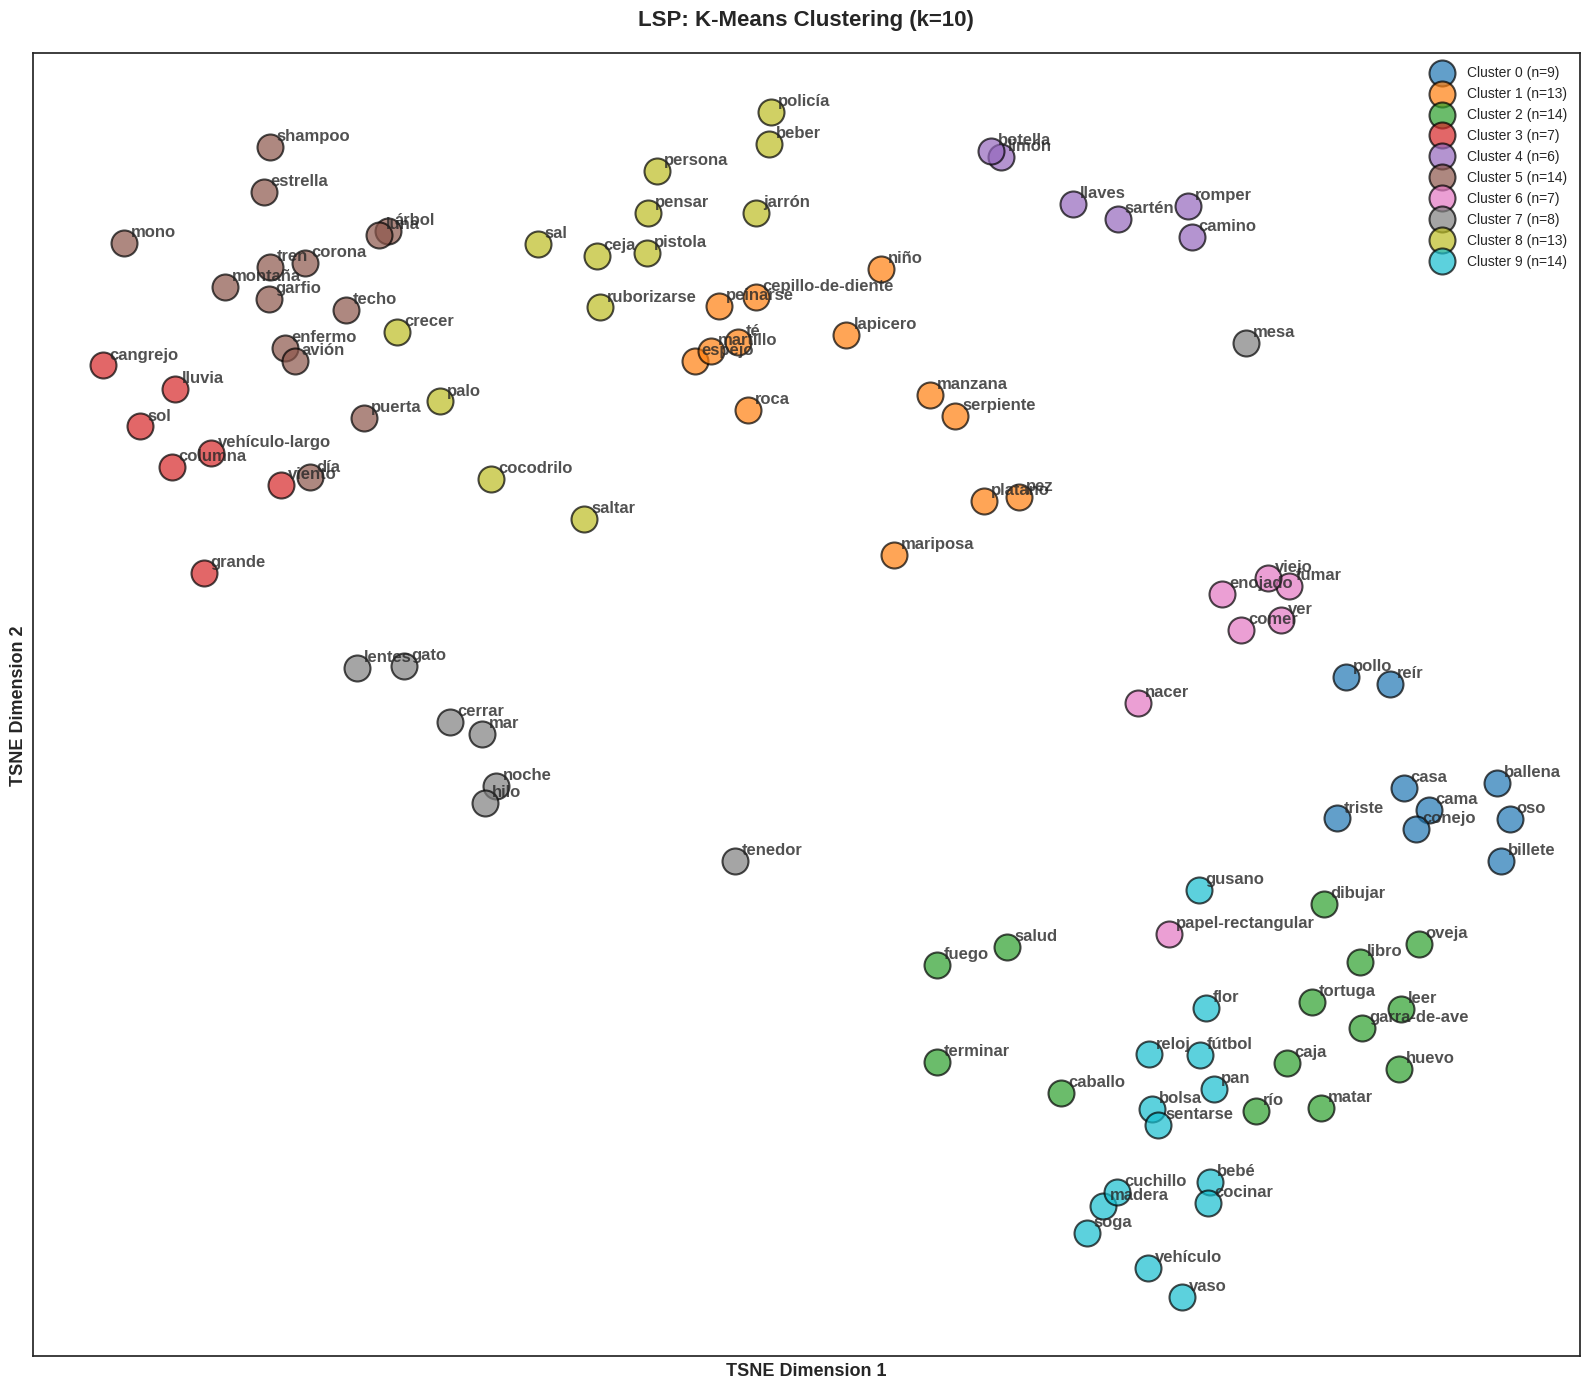

   ✅ emb_phono_median_LSP_MHIv5/emb_phono_median_LSP_MHIv5_k10_PCA_TSNE.png guardada


In [30]:
# ==============================================================================
# VISUALIZACIÓN 1: CLUSTERS K-MEANS
# ==============================================================================

print("\n" + "="*80)
print("🎨 VISUALIZACIÓN 1: CLUSTERS K-MEANS")
# Generar gráficas individuales
#plot_kmeans_clusters(asl_data, reduct_method, 'ASL', k_opt_asl, fileName[:-6]+'k'+str(k_opt_asl)+'_asl.png')
plot_kmeans_clusters(sign_data, signLanguage, k_opt, f"{fileName}/{fileName}_k{str(k_opt)}_{reduct_method["methodReduction"]}.png")


🎨 VISUALIZACIÓN 1: CLUSTERS K-MEANS

📊 Generando gráfica para LSP...


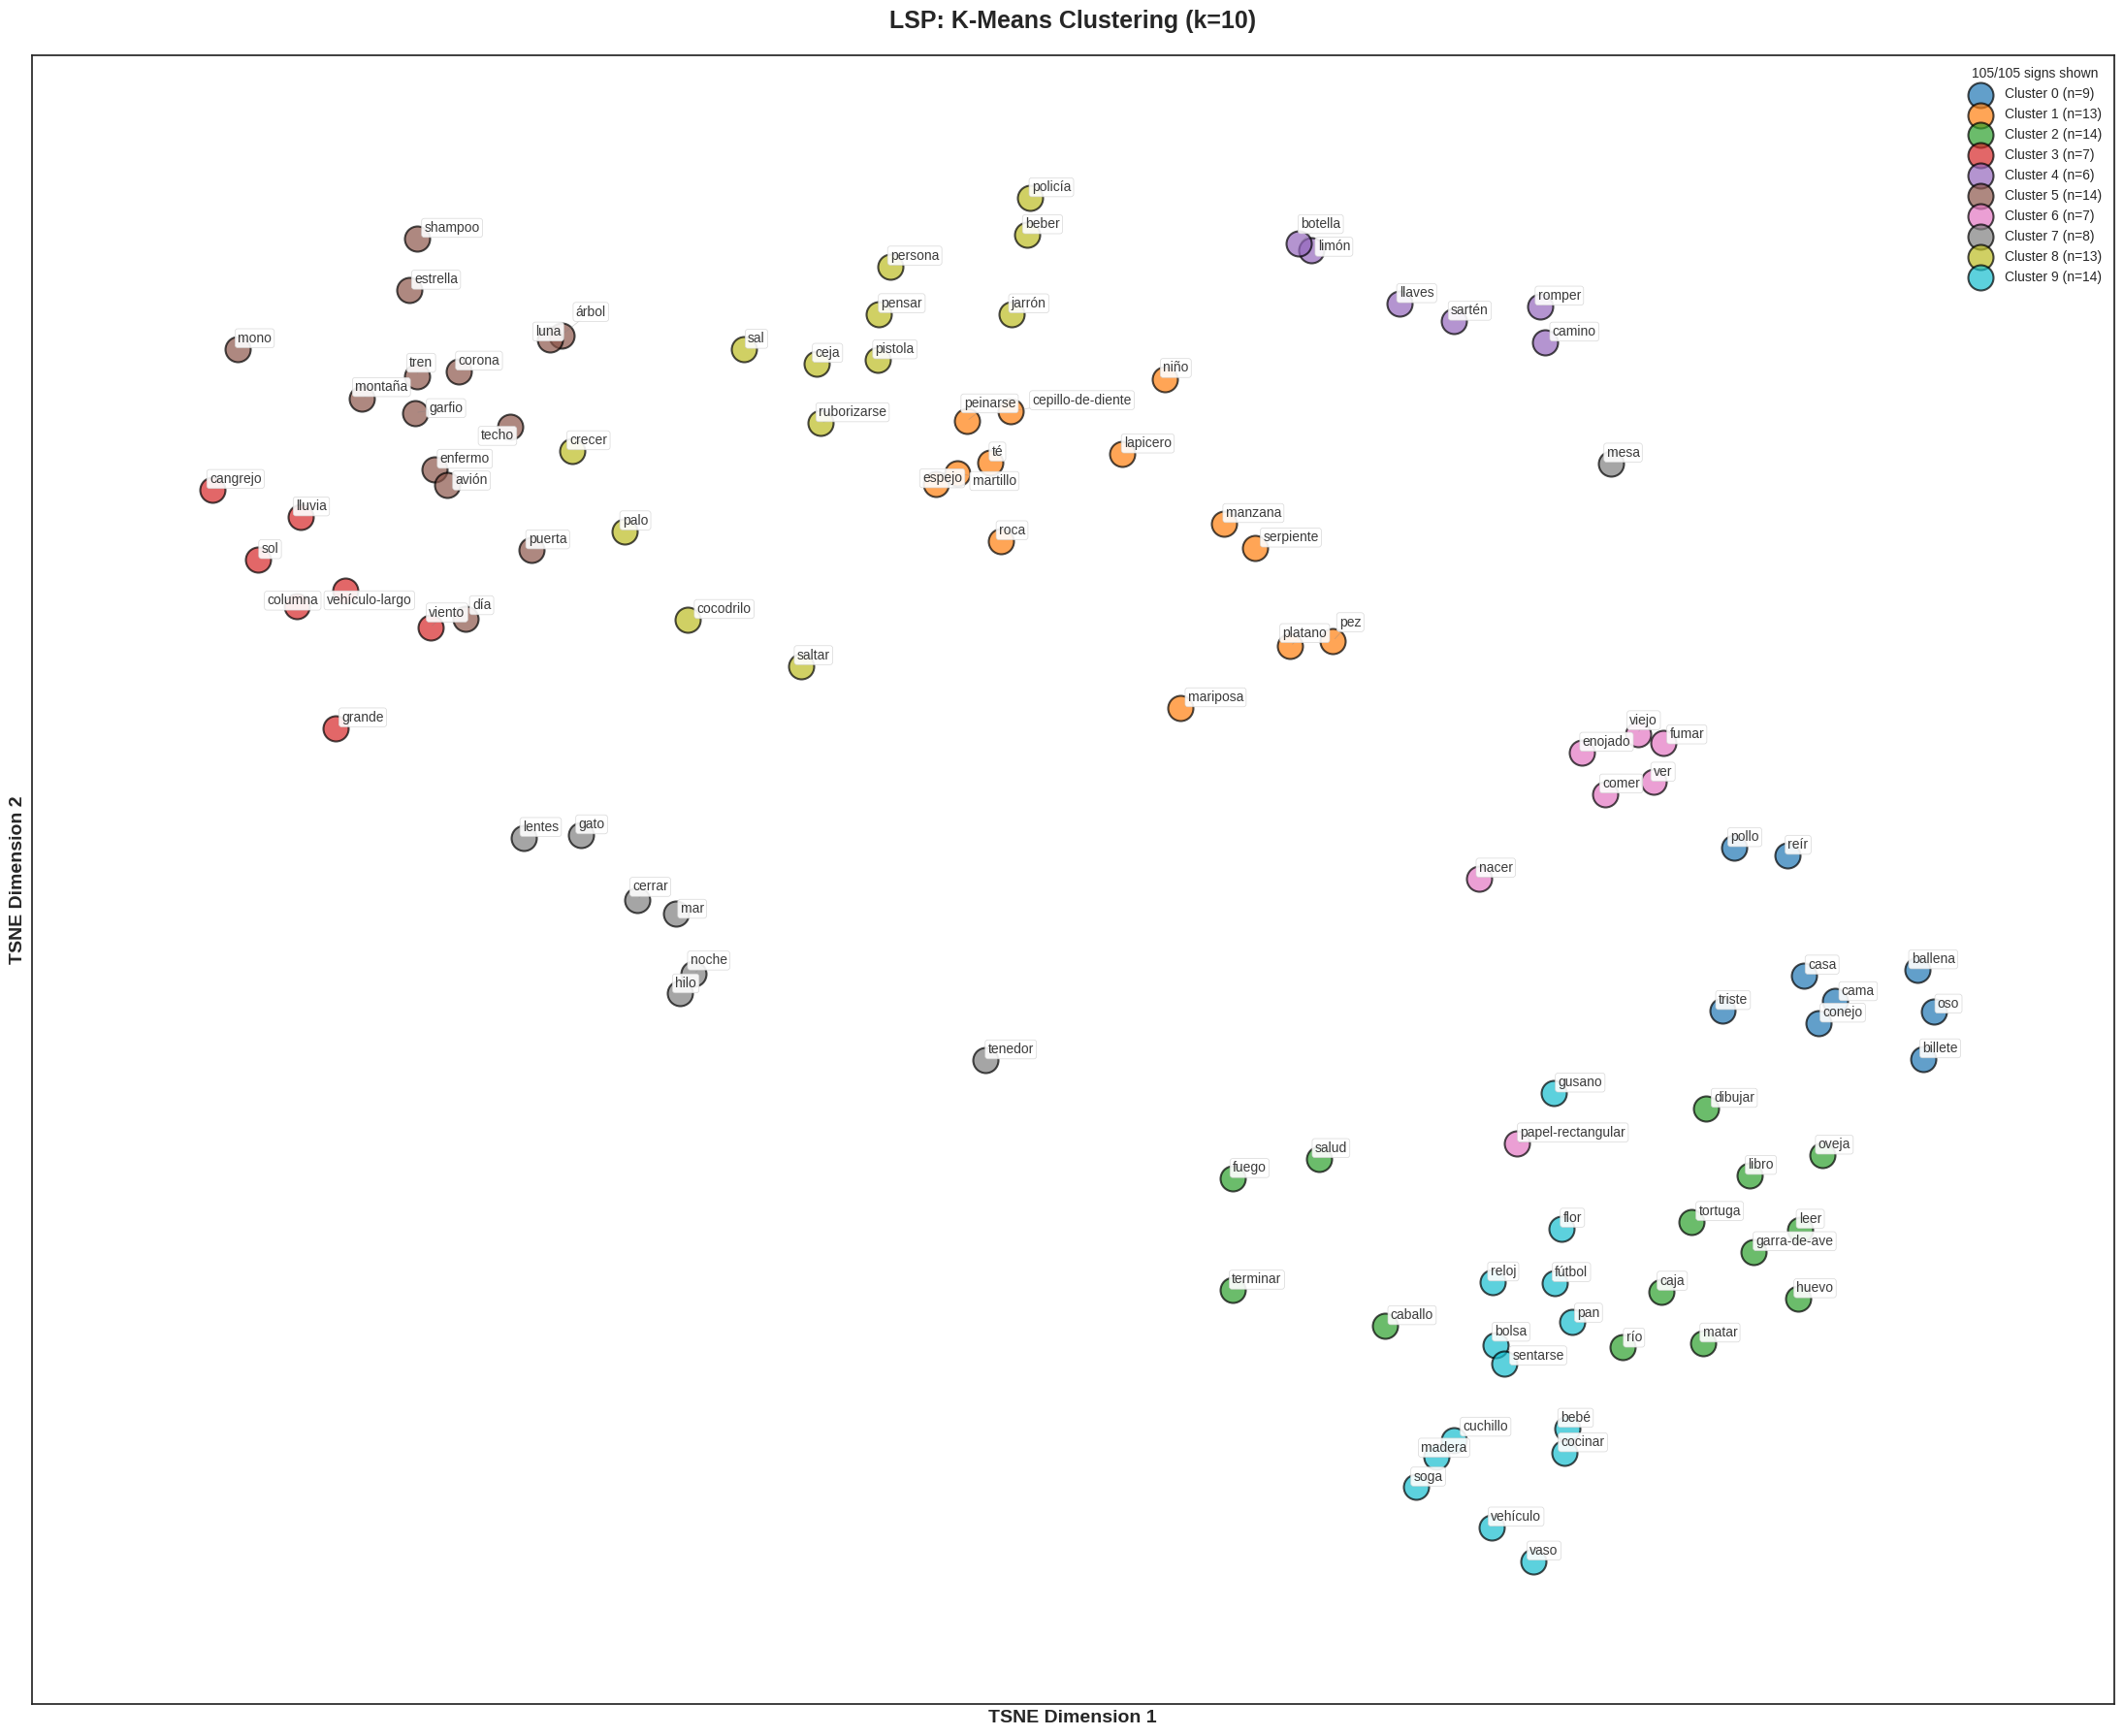

✅ emb_phono_median_LSP_MHIv5/emb_phono_median_LSP_MHIv5_k10_PCA_TSNE.png guardada (105 etiquetas)


In [31]:
# ==============================================================================
# VISUALIZACIÓN 2: CLUSTERS K-MEANS CON ETIQUETAS BLANCAS
# ==============================================================================

print("\n" + "="*80)
print("🎨 VISUALIZACIÓN 1: CLUSTERS K-MEANS")
# Generar gráficas individuales
#plot_kmeans_clusters(asl_data, reduct_method, 'ASL', k_opt_asl, fileName[:-6]+'k'+str(k_opt_asl)+'_asl.png')
plot_kmeans_clusters_new(sign_data, signLanguage, k_opt, f"{fileName}/{fileName}_k{str(k_opt)}_{reduct_method["methodReduction"]}.png")

In [32]:
# from google.colab import drive
# drive.mount('/content/drive')

In [33]:
# from google.colab import drive
# drive.mount('/content/drive')


🎨 VISUALIZACIÓN 2B: CLUSTERS + ICONICIDAD (TAMAÑO)

📊 Generando gráfica para LSP...
   🔹 Etiquetando 105 señas...


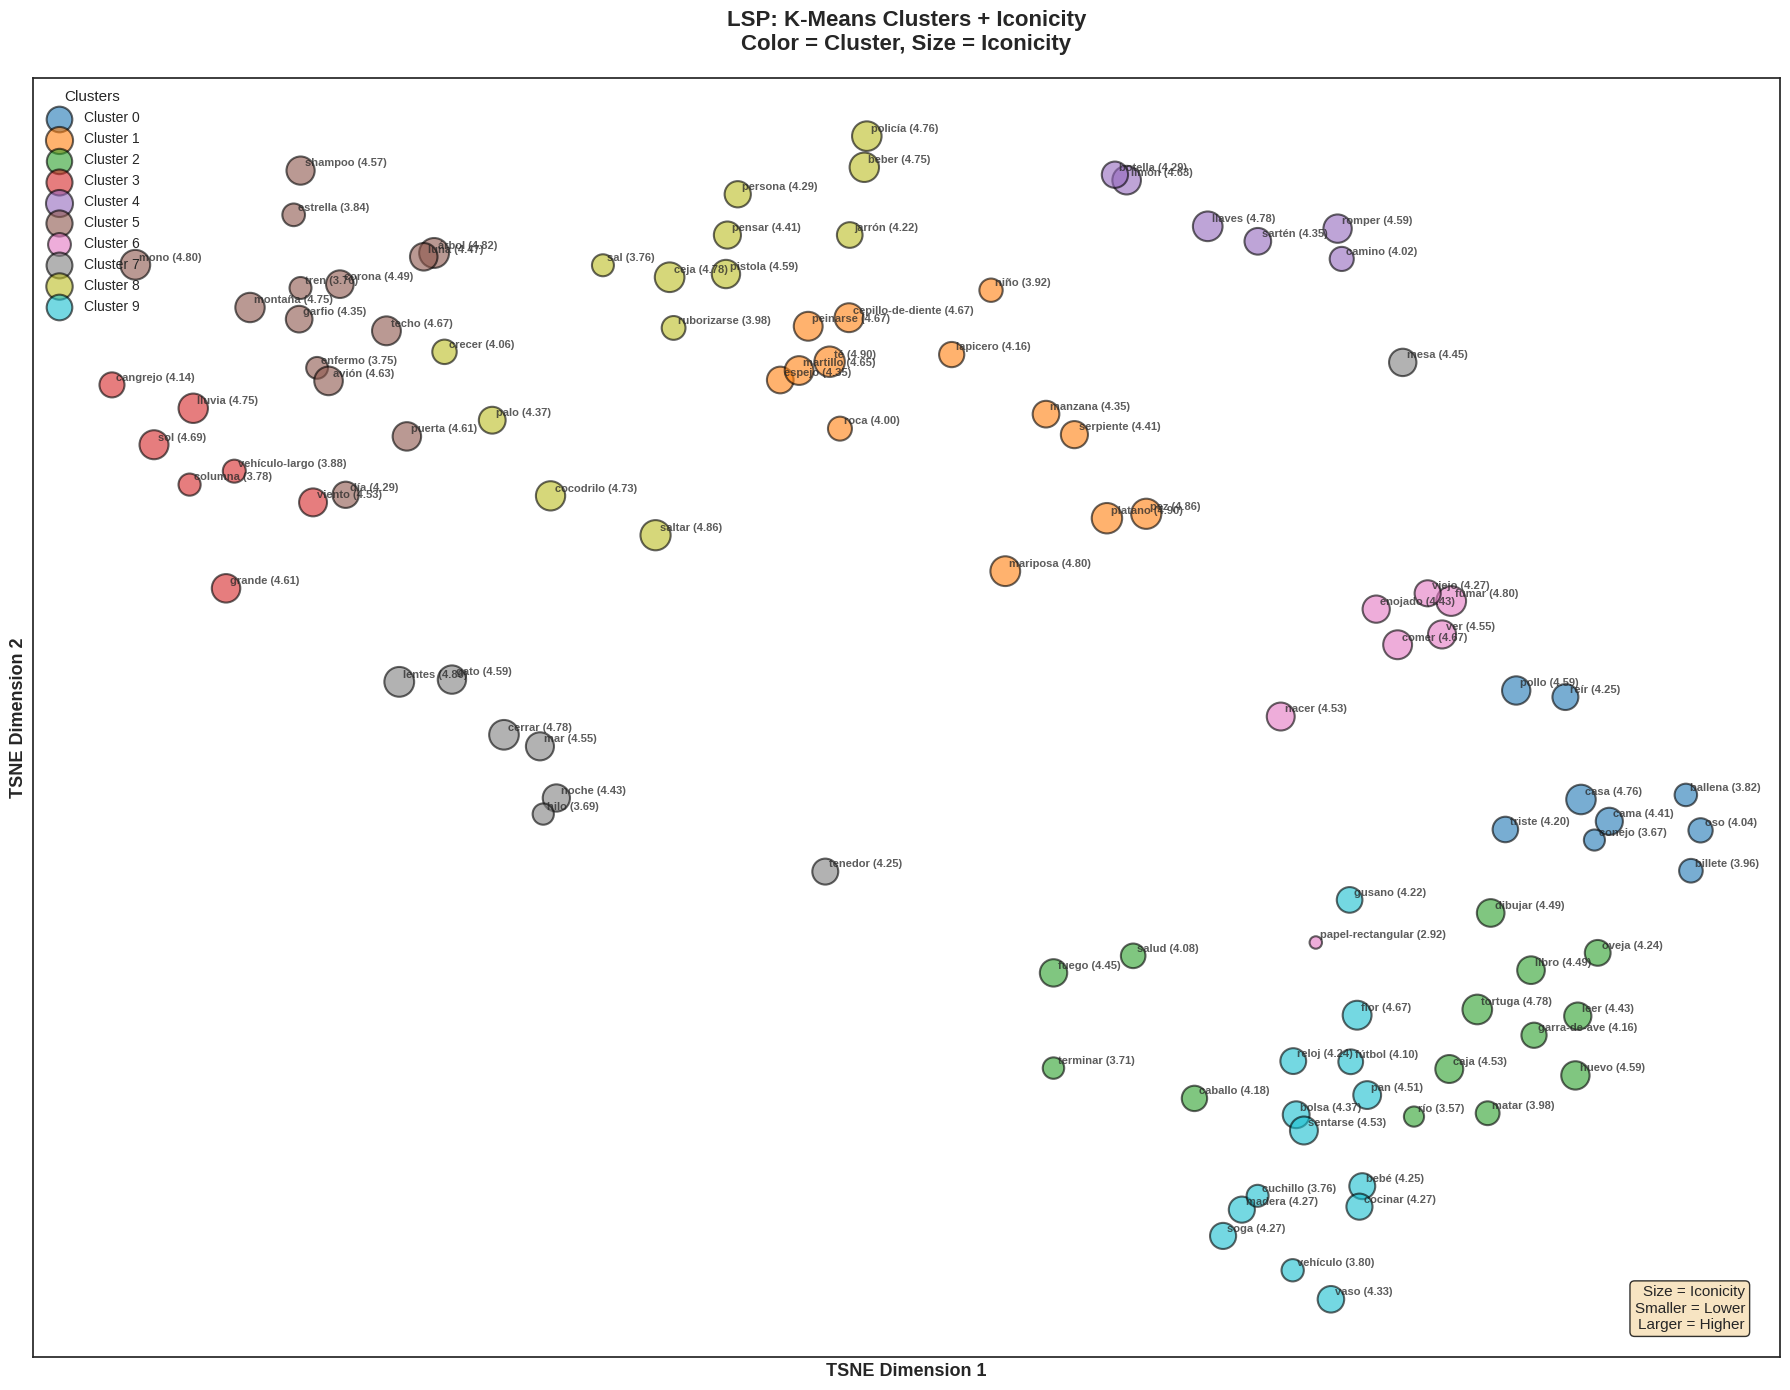

 emb_phono_median_LSP_MHIv5/emb_phono_median_LSP_MHIv5_iconSize_k10_PCA_TSNE.png guardada


In [34]:
# ==============================================================================
# VISUALIZACIÓN 3: CLUSTERS K-MEANS  (COLOR) + ICONICIDAD (TAMAÑO)
# ==============================================================================

print("\n" + "="*80)
print("🎨 VISUALIZACIÓN 2B: CLUSTERS + ICONICIDAD (TAMAÑO)")
# Generar gráficas
#plot_clusters_iconicity_size(asl_data, 'ASL', k_opt_asl, fileName[:-6]+'iconSize_k'+k_opt_asl+'_asl.png')

plot_clusters_iconicity_size(sign_data, signLanguage, k_opt, f"{fileName}/{fileName}_iconSize_k{str(k_opt)}_{reduct_method["methodReduction"]}.png")



🎨 VISUALIZACIÓN 2C: FACET GRID POR CLUSTER

 Generando facet grid para LSP...
 Cluster 0: Etiquetando 9 señas...
 Cluster 1: Etiquetando 13 señas...
 Cluster 2: Etiquetando 14 señas...
 Cluster 3: Etiquetando 7 señas...
 Cluster 4: Etiquetando 6 señas...
 Cluster 5: Etiquetando 14 señas...
 Cluster 6: Etiquetando 7 señas...
 Cluster 7: Etiquetando 8 señas...
 Cluster 8: Etiquetando 13 señas...
 Cluster 9: Etiquetando 14 señas...


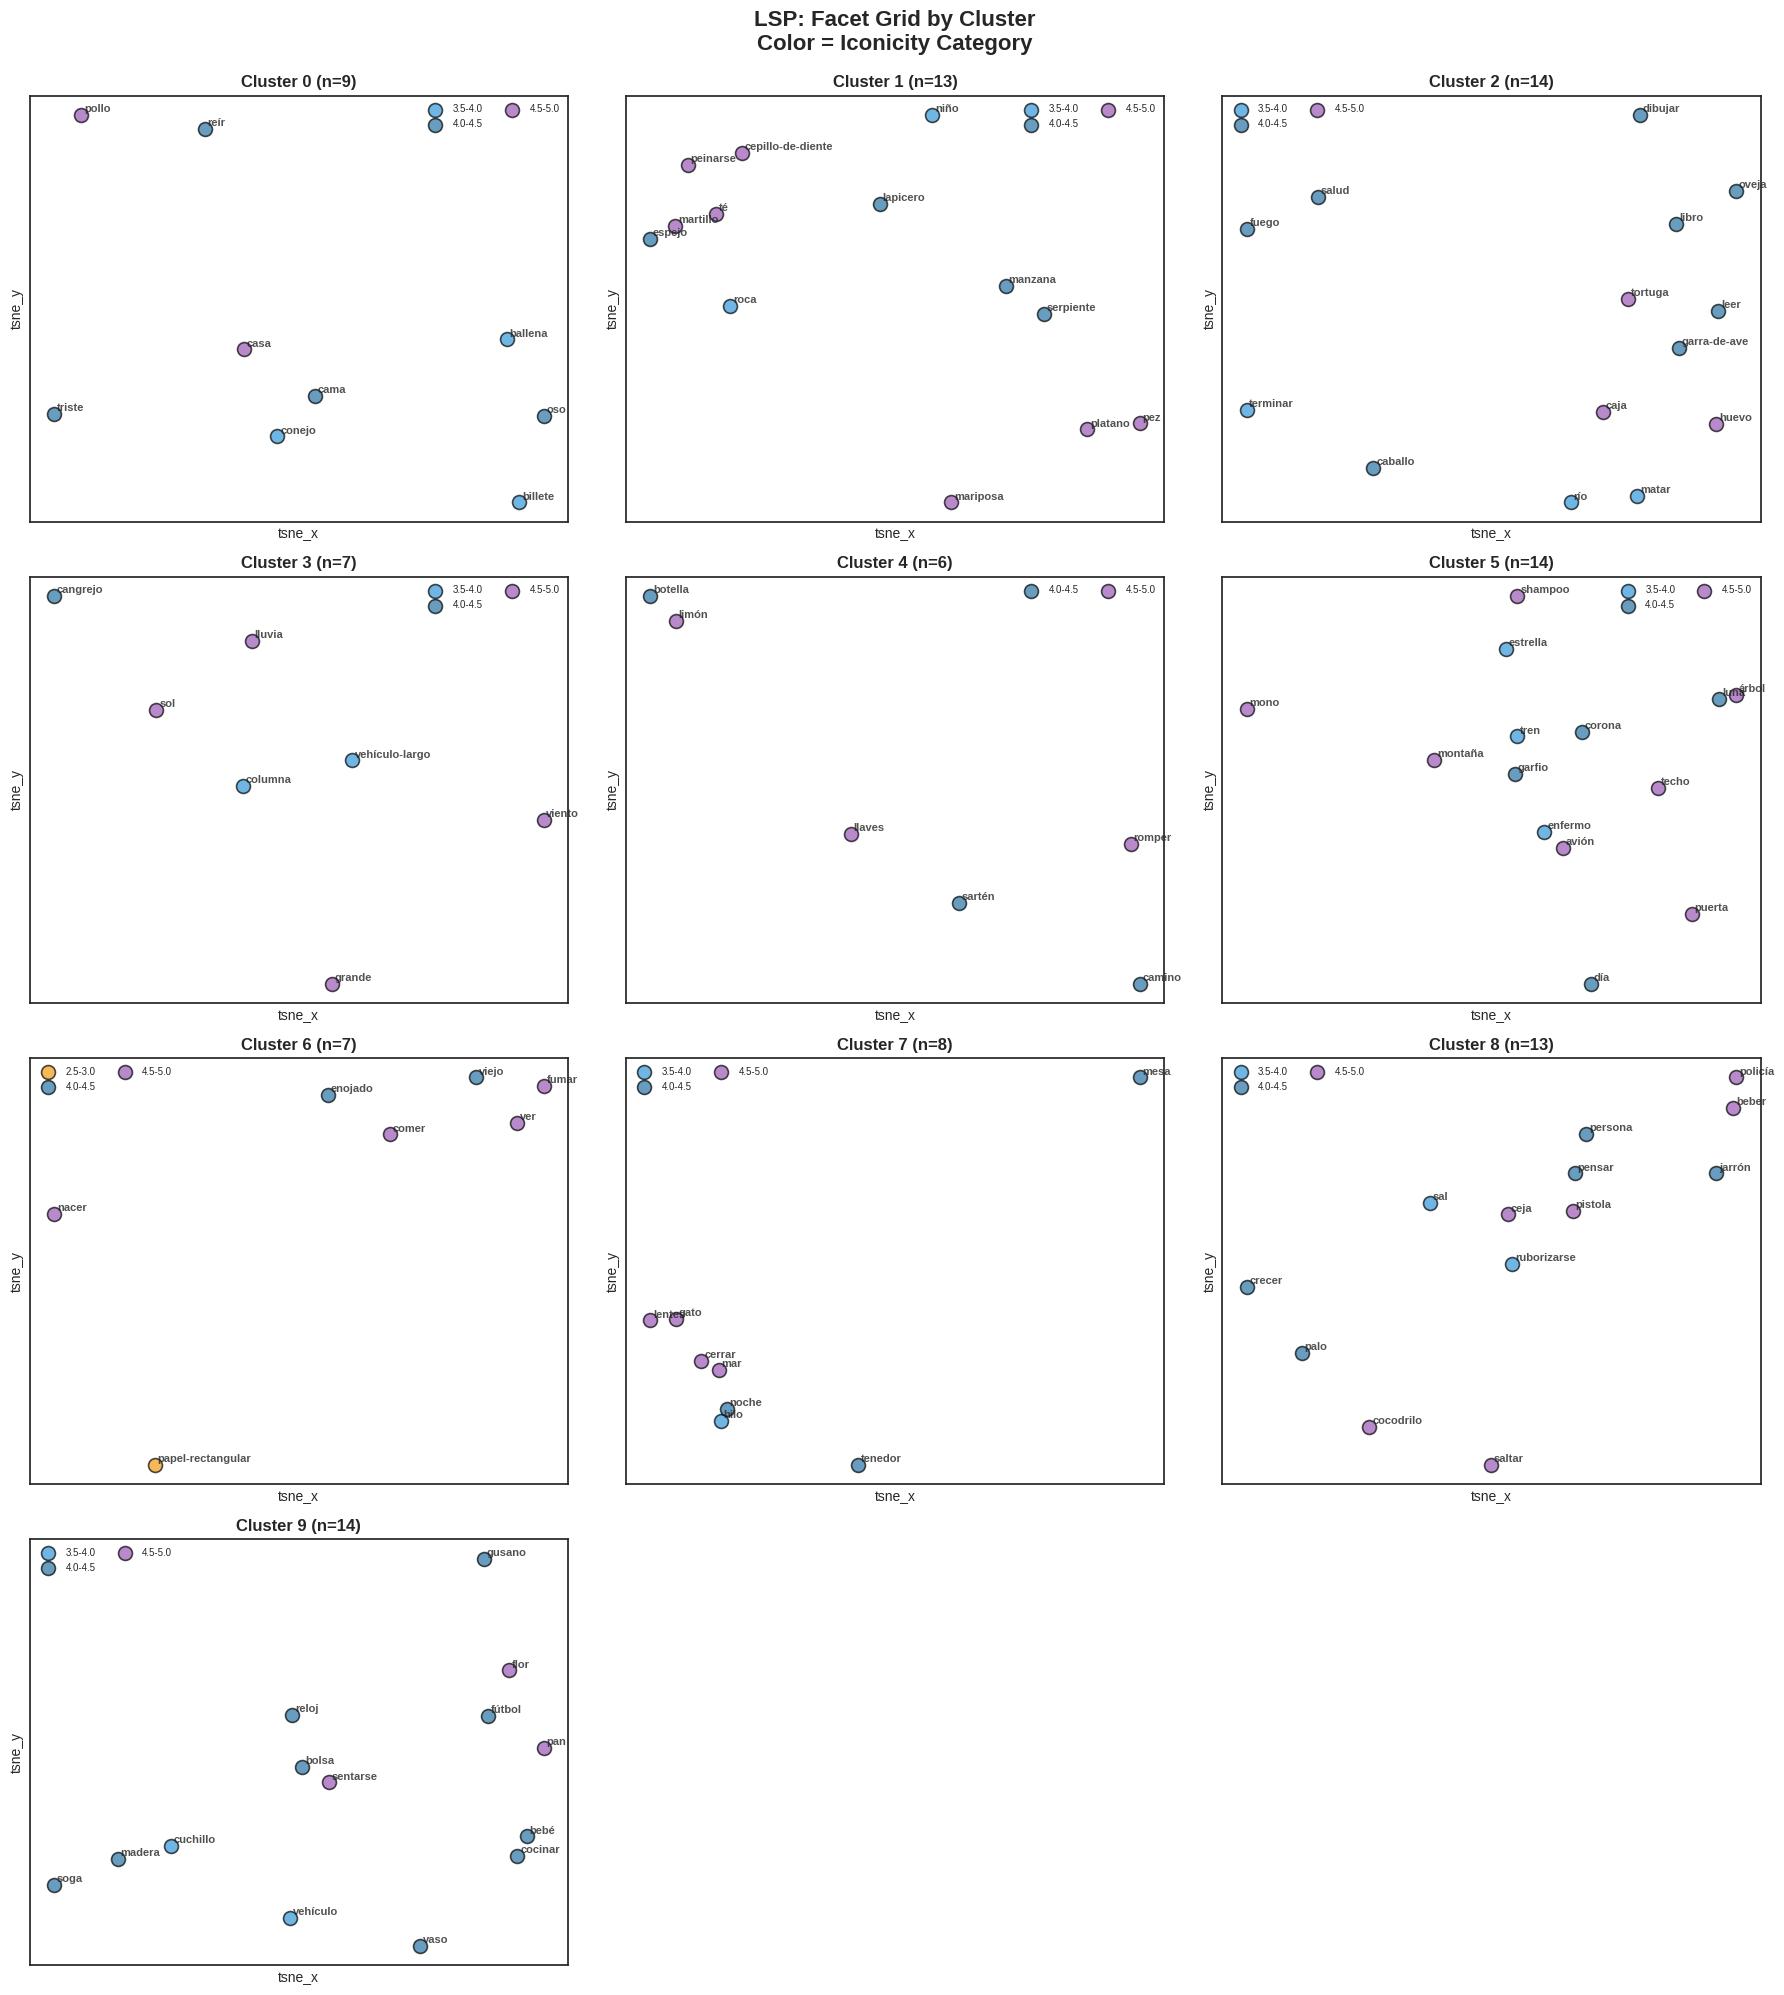

emb_phono_median_LSP_MHIv5/emb_phono_median_LSP_MHIv5_gridBy_k10_PCA_TSNE.png guardada


In [35]:
# ==============================================================================
# VISUALIZACIÓN 4: FACET GRID (SUBPLOT POR CLUSTER)
# ==============================================================================
print("\n" + "="*80)
print("🎨 VISUALIZACIÓN 2C: FACET GRID POR CLUSTER")
# Generar facet grids
#plot_facet_grid_clusters(asl_data, 'ASL', k_opt_asl, fileName[:-6]+'gridBy_k'+k_opt_asl+'_asl.png')

plot_facet_grid_clusters(sign_data,signLanguage, k_opt, f"{fileName}/{fileName}_gridBy_k{str(k_opt)}_{reduct_method["methodReduction"]}.png")


In [36]:

# ==============================================================================
# ESTADÍSTICAS DETALLADAS POR CLUSTER
# ==============================================================================

print("\n" + "="*80)
print("ESTADÍSTICAS DETALLADAS POR CLUSTER")
print("="*80)

# Analizar clusters
#stats_asl = analyze_clusters(asl_data, signLanguage, k_opt_asl)
stats_lsp = analyze_clusters(sign_data, signLanguage, k_opt)

# Guardar estadísticas
with open(f"{fileName}/{fileName}_{reduct_method["methodReduction"]}_cluster_statistics.txt", 'w', encoding='utf-8') as f:
    f.write(stats_lsp)

print("\n Estadísticas guardadas en: cluster_statistics.txt")



ESTADÍSTICAS DETALLADAS POR CLUSTER

LSP - ANÁLISIS DE CLUSTERS (k=10)

 CLUSTER 0:
   • Tamaño: 9 señas (8.6%)
   • Iconicidad: 4.19 ± 0.36 (rango: 3.67 - 4.76)
   • Top 5 más icónicas:
      CASA            → 4.76
      POLLO           → 4.59
      CAMA            → 4.41
      REÍR            → 4.25
      TRISTE          → 4.20
   • Todas las señas (9):
      BALLENA, BILLETE, CAMA, CASA, CONEJO, OSO, POLLO, REÍR, TRISTE

 CLUSTER 1:
   • Tamaño: 13 señas (12.4%)
   • Iconicidad: 4.51 ± 0.34 (rango: 3.92 - 4.90)
   • Top 5 más icónicas:
      PLATANO         → 4.90
      TÉ              → 4.90
      PEZ             → 4.86
      MARIPOSA        → 4.80
      PEINARSE        → 4.67
   • Todas las señas (13):
      CEPILLO-DE-DIENTE, ESPEJO, LAPICERO, MANZANA, MARIPOSA, MARTILLO, NIÑO, PEINARSE, PEZ, PLATANO, ROCA, SERPIENTE, TÉ

 CLUSTER 2:
   • Tamaño: 14 señas (13.3%)
   • Iconicidad: 4.26 ± 0.34 (rango: 3.57 - 4.78)
   • Top 5 más icónicas:
      TORTUGA         → 4.78
      HUEVO  

### **4. Exportar resultados**

In [37]:
sign_data

,word,EnglishGloss,iconicity,0,1,2,3,4,5,6,...,4061,4062,4063,icon_category,x,y,z,cluster,tsne_x,tsne_y
0,BEBÉ,BABY,4.254902,-0.003707,0.006492,-0.002747,-0.002082,0.002592,0.000421,0.001634,...,-0.007017,0.038015,0.025625,7,-0.606374,-0.220452,0.272849,9,1.973237,-0.294819
1,GATO,CAT,4.588235,0.000720,0.002715,0.001315,-0.003357,-0.000763,-0.001859,0.000411,...,-0.013198,-0.001803,-0.013114,8,0.267278,-0.314252,-0.276527,7,-4.802691,4.561154
2,GARRA-DE-AVE,BIRD-CLAW,4.156863,0.002340,0.002242,0.002392,-0.005215,-0.002592,-0.004770,-0.001031,...,-0.013118,0.027650,0.037004,7,-0.620652,-0.036059,-0.343836,2,3.251537,1.151786
3,PAPEL-RECTANGULAR,RECTANGULAR-PAPER,2.921569,-0.004624,0.007973,-0.003322,-0.002185,0.007068,0.000869,0.003827,...,-0.004268,0.025623,0.033404,4,-0.501913,0.147604,0.253999,6,1.627215,2.040992
4,SALTAR,JUMP,4.863636,-0.000006,0.004187,0.000610,-0.003376,0.000010,-0.002249,0.003332,...,-0.013112,-0.001642,-0.013027,8,0.205418,-0.192509,0.157828,8,-3.287095,5.945209
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,GARFIO,HOOK,4.352941,0.002267,0.003111,0.002062,-0.004056,-0.001028,-0.001920,-0.000272,...,-0.012652,-0.012498,-0.012567,7,0.568835,-0.116608,-0.255215,5,-5.939757,8.016222
101,LUNA,MOON,4.470588,0.000489,0.003511,0.001151,-0.003114,0.000208,-0.001024,0.001208,...,-0.012400,-0.012246,-0.012314,7,0.600430,0.119593,-0.116537,5,-5.012488,8.614086
102,SOL,SUN,4.686274,-0.001343,0.003595,-0.000726,-0.003620,0.001549,-0.000706,0.000346,...,-0.012555,-0.005846,-0.012469,8,0.517380,-0.397124,0.053352,3,-7.020165,6.812449
103,RÍO,RIVER,3.568627,-0.000807,0.006201,-0.000686,-0.003448,0.002098,-0.002025,0.002954,...,-0.002760,0.036346,0.025965,6,-0.691128,-0.191720,-0.008287,2,2.358074,0.372328


In [38]:

# ==============================================================================
# EXPORTAR RESULTADOS
# ==============================================================================

print("\n" + "="*80)
print("EXPORTANDO RESULTADOS")
print("="*80)

# Guardar DataFrames con resultados
sign_results = sign_data[['word', 'iconicity', 'cluster', #, 'icon_category'
                         'x', 'y', 'z']].copy()
# lsp_results = lsp_data[['word', 'iconicity', 'cluster', #, 'icon_category'
#                          'pc1', 'pc2', 'pc3', 'tsne_x', 'tsne_y']].copy()

sign_results.to_csv(f"{fileName}/{fileName}_kmeans_{reduct_method["methodReduction"]}_results_asl.csv", index=False)
# lsp_results.to_csv(fileName[:-6]+'kmeans_results.csv', index=False)

print("Resultados exportados:")
print("   • kmeans_results_ASL.csv")
print("   • kmeans_results_LSP.csv")


EXPORTANDO RESULTADOS
Resultados exportados:
   • kmeans_results_ASL.csv
   • kmeans_results_LSP.csv


In [39]:
  !zip -r emb_phono_median_LSP_MHIv5.zip emb_phono_median_LSP_MHIv5/

  adding: emb_phono_median_LSP_MHIv5/ (stored 0%)
  adding: emb_phono_median_LSP_MHIv5/emb_phono_median_LSP_MHIv5_PCA_TSNE_cluster_statistics.txt (deflated 69%)
  adding: emb_phono_median_LSP_MHIv5/emb_phono_median_LSP_MHIv5_elbow_PCA_TSNE.png (deflated 18%)
  adding: emb_phono_median_LSP_MHIv5/emb_phono_median_LSP_MHIv5_k10_PCA_TSNE.png (deflated 17%)
  adding: emb_phono_median_LSP_MHIv5/emb_phono_median_LSP_MHIv5_iconSize_k10_PCA_TSNE.png (deflated 12%)
  adding: emb_phono_median_LSP_MHIv5/emb_phono_median_LSP_MHIv5_kmeans_PCA_TSNE_results_asl.csv (deflated 49%)
  adding: emb_phono_median_LSP_MHIv5/emb_phono_median_LSP_MHIv5_gridBy_k10_PCA_TSNE.png (deflated 22%)


In [40]:
 from google.colab import files

 files.download("emb_phono_median_LSP_MHIv5.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>